In [2]:
from symbol import parameters

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

/var/folders/85/01jjdh9j2tqcvzll8t3sf2xw0000gp/T/ipykernel_87697/2927176390.py:1: DeprecationWarning: The symbol module is deprecated and will be removed in future versions of Python
  from symbol import parameters


In [3]:
words = open("/Users/phucnguyen/PyCharmMiscProject/2.makemore/names.txt").read().splitlines()
chars = sorted(set(''.join(words)))

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
atoi = {s:i+1 for i,s in enumerate(chars)}
atoi['.'] = 0
itoa = {i:s for s,i in atoi.items()}
print(itoa)
print(atoi)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [5]:
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  # print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = atoi[ch]
    X.append(context)
    Y.append(ix)
    # print(''.join(itoa[i] for i in context), '--->', itoa[ix])
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [7]:
n1 = int(0.8 * X.shape[0])
n2 = int(0.9 * X.shape[0])
Xtr, Xdev, Xts = X.tensor_split((n1, n2), dim=0)
Ytr, Ydev, Yts = Y.tensor_split((n1, n2), dim=0)

Layer 1: Lookup table (27, 3, 2)
Layer 2: Hidden 100
Layer 3: Output 27

In [34]:
vocab_size = 27
hidden_layer = 200
embd_dim = 10
dim = block_size * embd_dim
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embd_dim), generator=g)
W1 = torch.randn(dim, hidden_layer, generator=g) * (5/3)/((block_size * embd_dim) ** 0.5)
b1 = torch.randn(hidden_layer, generator=g) * 0.01
W2 = torch.randn((hidden_layer, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [9]:
sum(p.nelement() for p in parameters)

11897

In [37]:
loss = 0
lre = torch.linspace(0, 0.2, 1000)

lri = []
lossi = []
step = []

for i in range(100000):
    # forward pass
    ix = torch.randint(0, Xtr.shape[0], (32,))  # (32, 2, 2)

    emp = C[Xtr[ix]]
    h = torch.tanh(emp.view(-1, dim) @ W1 + b1)
    logits = h @ W2 + b2

    # backward pass
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 10000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    step.append(i)
    lossi.append(loss.item())
    if i % 10000 == 0:
        print(loss.item())

2.4305801391601562
2.191525459289551
2.5923242568969727
1.806645393371582
2.0912187099456787
1.9455058574676514
2.1357295513153076
1.66041898727417
1.8079982995986938
2.199723720550537


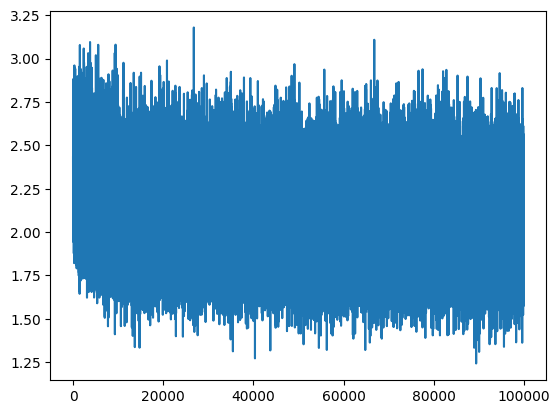

In [38]:
plt.plot(step, lossi)

In [27]:
emp = C[Xtr]
h = torch.tanh(emp.view(-1, dim) @ W1 + b1)
logits = h @ W2 + b2
# backward pass
loss = F.cross_entropy(logits, Ytr)
loss.item()

2.06516695022583

In [28]:
emp = C[Xdev]
h = torch.tanh(emp.view(-1, dim) @ W1 + b1)
logits = h @ W2 + b2
# backward pass
loss = F.cross_entropy(logits, Ydev)
loss.item()

2.35284686088562